# Indian Sign Language Recognition using Deep Learning

This project aims to recognize Indian Sign Language (ISL) hand gestures using a Convolutional Neural Network (CNN). The model is trained on image data and predicts the corresponding sign class.

## Problem Statement

Communication can be difficult for deaf and hard-of-hearing individuals who use sign language. The goal of this project is to build a deep learning model that can identify Indian Sign Language gestures from images and help improve accessibility.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [2]:
DATASET_PATH = r"data"

print("Dataset Path:", DATASET_PATH)
print("Folders Found:", len(os.listdir(DATASET_PATH)))

Dataset Path: data
Folders Found: 24


In [3]:
classes = sorted(os.listdir(DATASET_PATH))

print("Total Classes:", len(classes))
print(classes)

Total Classes: 24
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


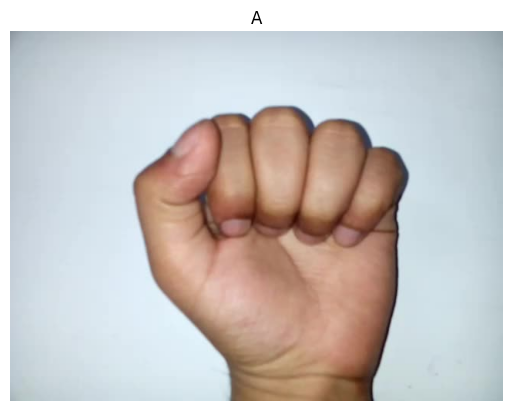

In [4]:
sample_class = classes[0]

sample_folder = os.path.join(DATASET_PATH, sample_class)

sample_image = os.listdir(sample_folder)[0]

img_path = os.path.join(sample_folder, sample_image)

img = cv2.imread(img_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title(sample_class)
plt.axis("off")
plt.show()

In [5]:
X = []
y = []

IMG_SIZE = 128

for label in classes:
    
    folder_path = os.path.join(DATASET_PATH, label)
    
    for image_name in os.listdir(folder_path):
        
        image_path = os.path.join(folder_path, image_name)
        
        img = cv2.imread(image_path)
        
        if img is not None:
            
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            
            X.append(img)
            y.append(label)

print("Images Loaded Successfully")

Images Loaded Successfully


In [6]:
X = np.array(X, dtype="float32")
y = np.array(y)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (4972, 128, 128, 3)
y Shape : (4972,)


## Dataset Description

The dataset contains images of different Indian Sign Language hand gestures. Each folder represents a unique sign class and contains multiple images of that gesture.

Total Classes: 24
Total Images: 4972

In [7]:
X = X / 255.0

print("Min Value :", X.min())
print("Max Value :", X.max())

Min Value : 0.0
Max Value : 1.0


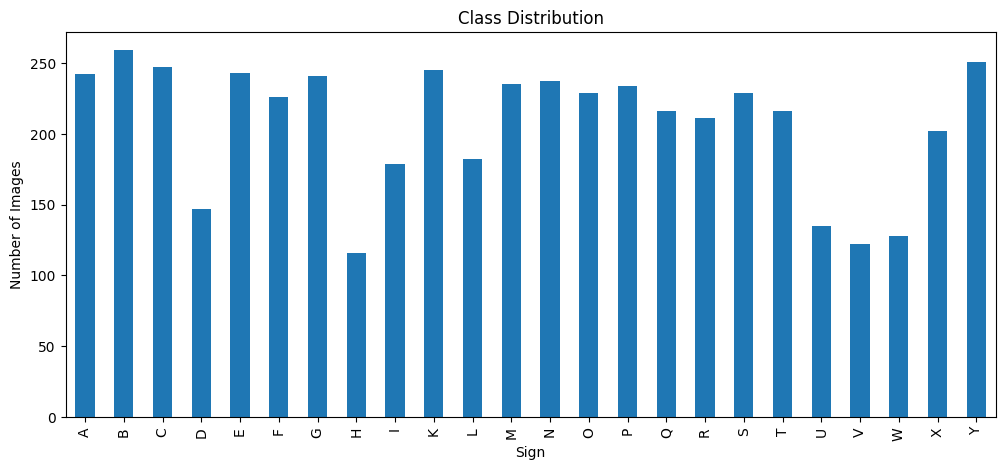

A    242
B    259
C    247
D    147
E    243
F    226
G    241
H    116
I    179
K    245
L    182
M    235
N    237
O    229
P    234
Q    216
R    211
S    229
T    216
U    135
V    122
W    128
X    202
Y    251
Name: count, dtype: int64


In [8]:
class_counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(12,5))
class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Sign")
plt.ylabel("Number of Images")
plt.show()

print(class_counts)

In [9]:
heights = []
widths = []

for label in classes:
    folder = os.path.join(DATASET_PATH, label)

    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))

        if img is not None:
            h, w, _ = img.shape
            heights.append(h)
            widths.append(w)

print("Min Height:", min(heights))
print("Max Height:", max(heights))

print("Min Width:", min(widths))
print("Max Width:", max(widths))

Min Height: 480
Max Height: 1920
Min Width: 640
Max Width: 1920


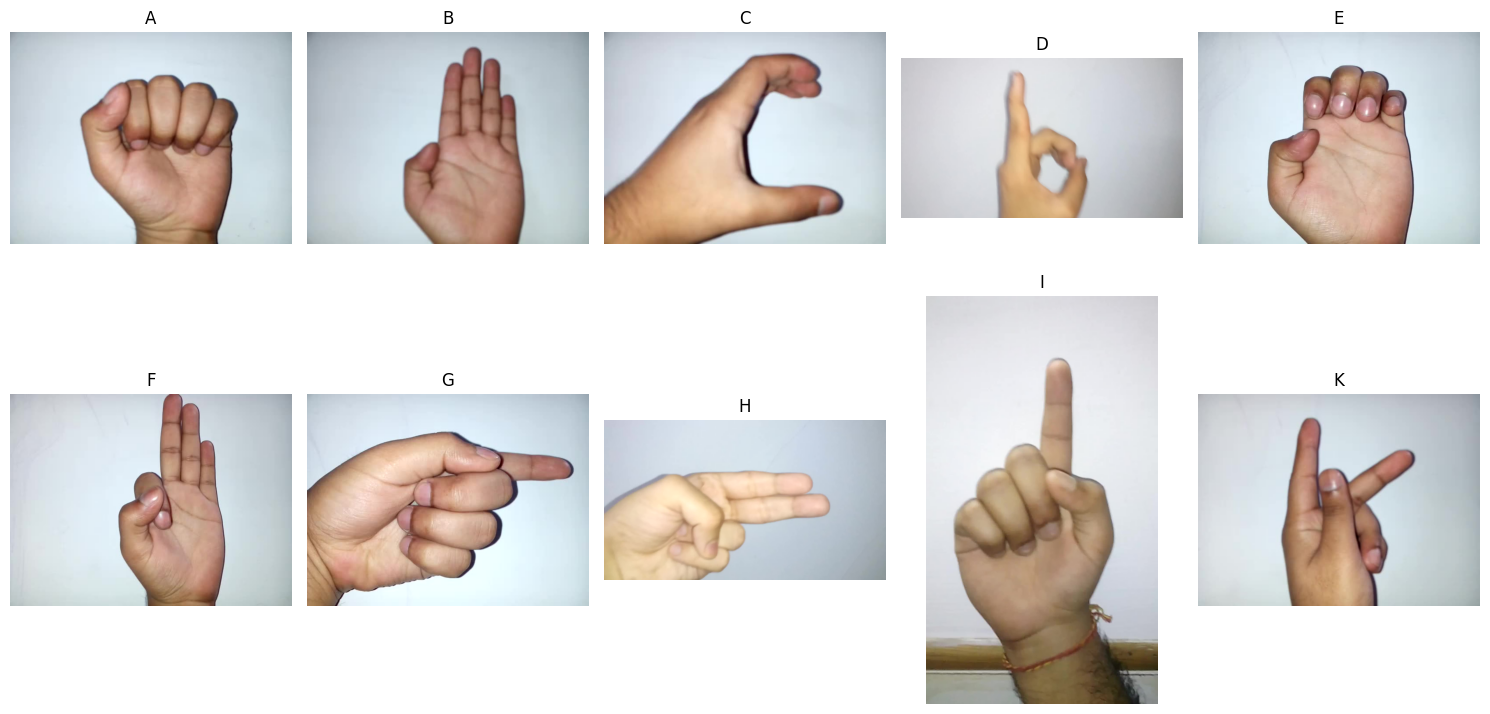

In [10]:
plt.figure(figsize=(15,8))

for i, label in enumerate(classes[:10]):

    folder = os.path.join(DATASET_PATH, label)

    img_name = os.listdir(folder)[0]

    img = cv2.imread(os.path.join(folder, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

Before training the model, the dataset was explored to understand the distribution of classes and visualize sample images from different sign categories.

In [11]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Number of Classes:", len(label_encoder.classes_))
print(label_encoder.classes_)

Number of Classes: 24
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S'
 'T' 'U' 'V' 'W' 'X' 'Y']


In [12]:
y_encoded = to_categorical(y_encoded)

print("Encoded Label Shape:", y_encoded.shape)

Encoded Label Shape: (4972, 24)


## Image Preprocessing

The images were resized to 128×128 pixels and normalized to improve model performance. Labels were encoded into numerical format and converted into one-hot vectors for multi-class classification.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Images : (3977, 128, 128, 3)
Testing Images : (995, 128, 128, 3)
Training Labels : (3977, 24)
Testing Labels : (995, 24)


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)

In [15]:
datagen.fit(X_train)

print("Data Augmentation Ready")

Data Augmentation Ready


## Feature Engineering

Data augmentation techniques were explored to improve model generalization. Different preprocessing and training approaches were tested to obtain the best model performance.

## Model Development

A Convolutional Neural Network (CNN) was developed using TensorFlow and Keras. The model consists of convolutional layers, batch normalization, max pooling, dropout, and dense layers for feature extraction and classification.

In [16]:
rom tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(24, activation='softmax'))

model.summary()

C:\Users\Om Mishra\.conda\envs\aviation_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │           3,096 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,552,920 (25.00 MB)

 Trainable params: 6,552,472 (25.00 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 87s 655ms/step - accuracy: 0.2824 - loss: 3.2540 - val_accuracy: 0.0422 - val_loss: 11.5523
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 83s 662ms/step - accuracy: 0.4491 - loss: 2.0356 - val_accuracy: 0.0955 - val_loss: 12.0476
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 83s 664ms/step - accuracy: 0.5401 - loss: 1.7010 - val_accuracy: 0.3065 - val_loss: 4.8891
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 80s 639ms/step - accuracy: 0.5999 - loss: 1.4758 - val_accuracy: 0.6824 - val_loss: 1.1410
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 85s 665ms/step - accuracy: 0.6668 - loss: 1.2245 - val_accuracy: 0.8834 - val_loss: 0.4840
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 143s 672ms/step - accuracy: 0.7051 - loss: 1.0795 - val_accuracy: 0.7106 - val_loss: 0.9620
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 85s 676ms/step - accuracy: 0.7473 - loss: 0.9735 - val_accuracy: 0.6764 - val_loss: 1.2538
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 648ms/step - accuracy: 0.7644 - loss

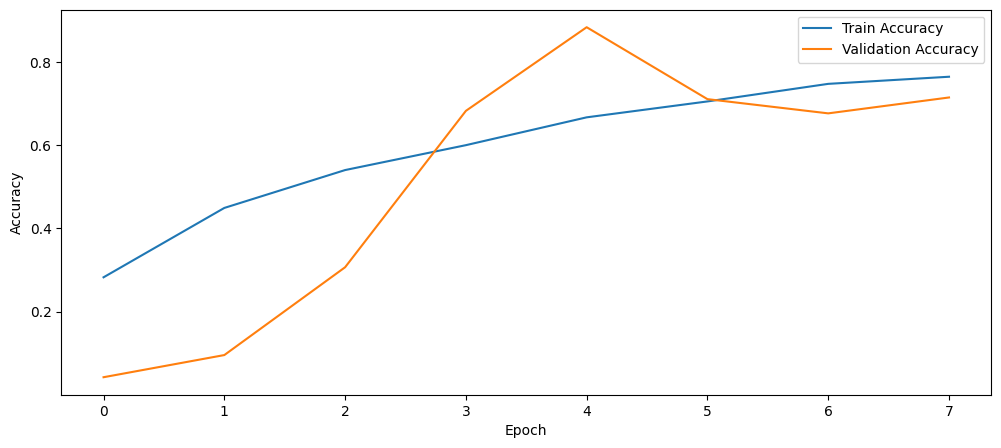

In [20]:
plt.figure(figsize=(12,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Training Performance

Training and validation accuracy were monitored during training to evaluate the learning behavior of the model.

In [21]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.8834 - loss: 0.4840
Test Loss : 0.48398011922836304
Test Accuracy : 0.8834170699119568


In [23]:
print("Best Accuracy:", max(history.history['val_accuracy']))

Best Accuracy: 0.8834170699119568


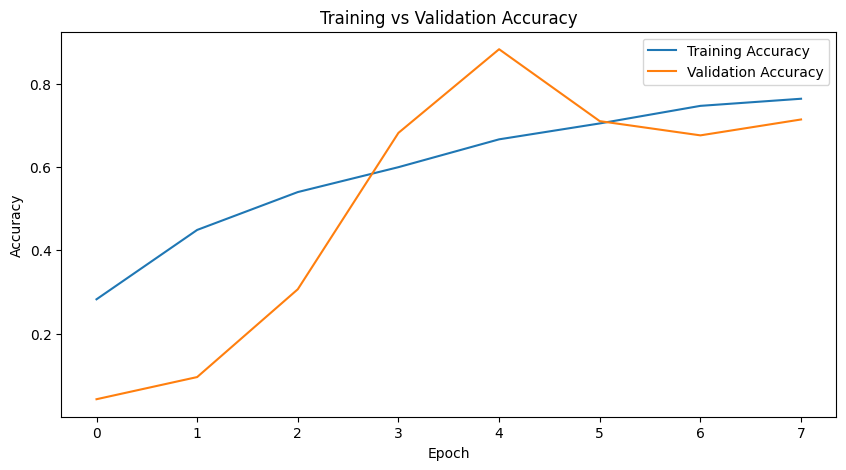

In [24]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

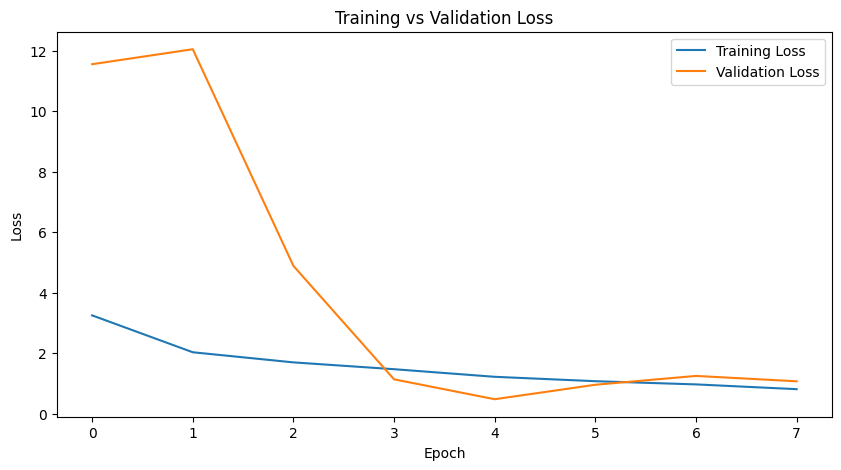

In [25]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step


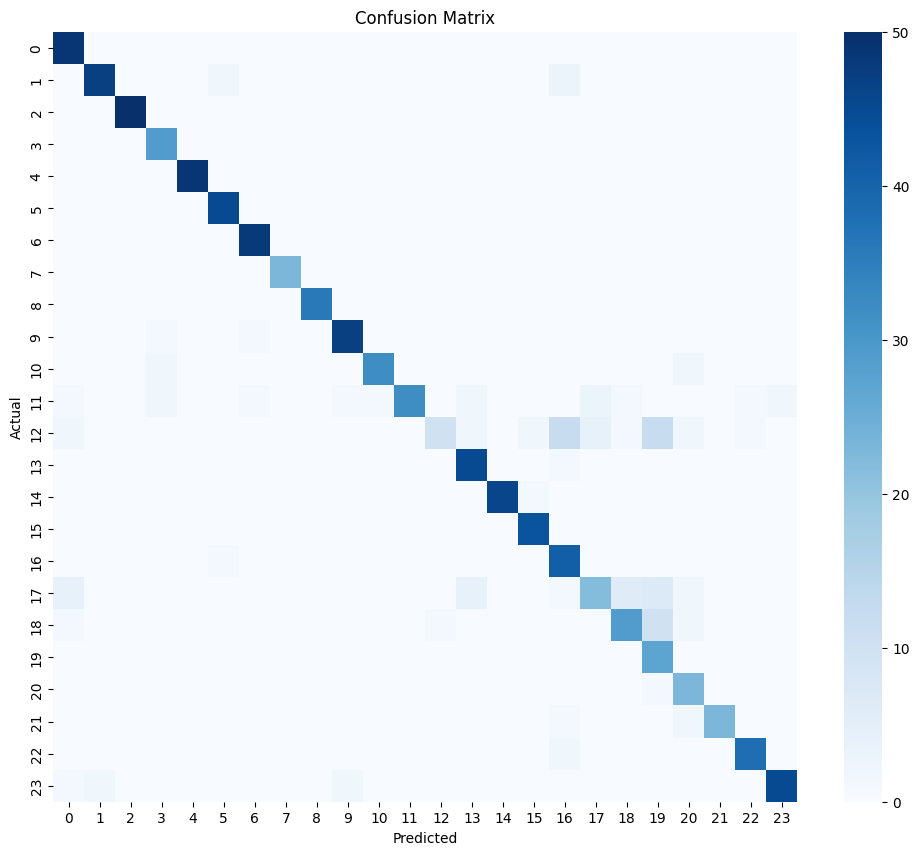

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Confusion Matrix

A confusion matrix was generated to visualize the model's classification performance across all sign language classes.

In [27]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_classes,
        y_pred_classes,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       0.84      1.00      0.92        49
           B       0.96      0.90      0.93        52
           C       1.00      1.00      1.00        50
           D       0.85      1.00      0.92        29
           E       1.00      1.00      1.00        49
           F       0.94      1.00      0.97        45
           G       0.96      1.00      0.98        48
           H       1.00      1.00      1.00        23
           I       1.00      1.00      1.00        36
           K       0.94      0.96      0.95        49
           L       0.97      0.89      0.93        36
           M       1.00      0.68      0.81        47
           N       0.91      0.21      0.34        48
           O       0.85      0.98      0.91        46
           P       1.00      0.98      0.99        47
           Q       0.93      1.00      0.97        43
           R       0.67      0.98      0.80        42
           S       0.76    

## Classification Report

Precision, Recall, and F1-Score were calculated for each class to obtain a detailed evaluation of the model's performance.

In [28]:
model.save("isl_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [29]:
from tensorflow.keras.models import load_model

saved_model = load_model("isl_model.h5")

print("Model Loaded Successfully")

Model Loaded Successfully


## Conclusion

A CNN-based Indian Sign Language Recognition system was successfully developed and evaluated. The model achieved an accuracy of approximately 88% on the test dataset. This project demonstrates the use of deep learning techniques for gesture recognition and can be extended to real-time sign language translation systems in the future.